## Looking at cosine decay of LRs. Used the CosineAnnealingLR below, might explore more options later. 

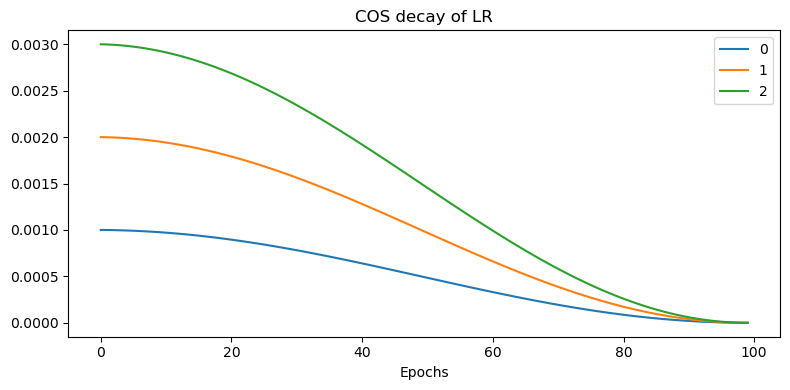

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import math
# lr_start = 1e-4 #1e-N ==> 0.(N-1)1, eg 1e-4==> 0.0001

def cos_annealing_lr(lr_max, lr_min, curr_epoch, max_epoch):
    eta_range = lr_min + 0.5 *(lr_max - lr_min)
    cosine_sched = (1 + math.cos( (curr_epoch * math.pi) / max_epoch))
    lr_t = eta_range * cosine_sched
    return lr_t

lr_list = [1e-3, 2e-3, 3e-3]
max_epoch = 100 # ensures we get 1-100 including the last index
epochs = np.arange(1,max_epoch+1,1)

fig, ax = plt.subplots(figsize=(8,4))
all_lr_versions = []
for i, eta in enumerate(lr_list):
    list_cosine_decay_lr = []
    for t in epochs:
        lr_max = eta # current eta based on lr_list
        lr_min = lr_max * 1e-4 #what ever the inital one is and 4 magnitudes smaller
        curr_epoch = t
        max_epoch = max_epoch
        lr_t =  cos_annealing_lr(lr_max, lr_min, curr_epoch, max_epoch) #lr at current epoch
        list_cosine_decay_lr.append(lr_t)

    all_lr_versions.append(list_cosine_decay_lr)

    ax.plot(all_lr_versions[i], label=f"{i}")
    ax.set_title("COS decay of LR")
    ax.set_xlabel("Epochs")
    plt.legend()

plt.tight_layout()
plt.show()
